# Evaluación final — Riesgo de retraso en el pago

## Objetivo del notebook

El objetivo de este notebook es realizar la evaluación final del sistema predictivo sobre el conjunto de test temporal.

Por primera vez en el proyecto se utilizará el período de test, que ha permanecido completamente reservado durante:

- EDA;
- feature engineering;
- selección de features;
- selección de algoritmo;
- análisis de threshold;
- interpretabilidad;
- comparación de modelos;
- calibración.

La finalidad es comprobar si las decisiones tomadas utilizando únicamente train y validation generalizan correctamente a un período futuro no utilizado durante el desarrollo.

## Configuración congelada

Antes de abrir test se han fijado las siguientes decisiones:

### Features

Se utilizarán las 34 features correspondientes al **Modelo C**:

- características de la factura actual;
- contexto temporal;
- histórico comercial del cliente;
- comportamiento histórico de pago;
- comportamiento reciente;
- variables relativas al importe;
- indicadores de disponibilidad de histórico.

### Algoritmo

`LogisticRegression`

La regresión logística fue seleccionada porque:

- presenta el mejor PR-AUC sobre validation;
- presenta un ROC-AUC muy elevado;
- mantiene un Recall alto;
- muestra una elevada estabilidad entre train y validation;
- supera o iguala a modelos de mayor complejidad;
- mantiene una mayor interpretabilidad.

### Calibración

No se utilizará calibración externa.

Las estrategias Sigmoid e Isotonic fueron evaluadas, pero ninguna mejoró el sistema completo respecto al Modelo C original entrenado utilizando todo train.

### Threshold

Se utilizará:

`threshold = 0.40`

Este punto fue seleccionado utilizando exclusivamente validation.

Con este threshold se obtiene un compromiso operativo entre:

- Recall superior al 90 %;
- Precision razonable;
- menor número de falsas alarmas que el threshold que maximiza F2.

## Regla de evaluación

El conjunto de test se utilizará una única vez.

Los resultados obtenidos en test no se utilizarán para:

- modificar features;
- cambiar el algoritmo;
- recalibrar;
- seleccionar un nuevo threshold;
- optimizar hiperparámetros.

Por tanto, las métricas obtenidas en este notebook representarán la estimación final de generalización temporal del sistema.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    brier_score_loss,
    log_loss,
)

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)

In [2]:
PROJECT_ROOT = Path("..")

GOLD_DIR = (
    PROJECT_ROOT
    / "data"
    / "gold"
)

GOLD_FILE = (
    GOLD_DIR
    / "gold_invoice_risk.parquet"
)

print(
    GOLD_FILE.resolve()
)

C:\Users\jesus\OneDrive\Documents\Evolve Data Science\portfolio\sistema_predictivo_tesoreria_y_riesgo_de_impago\data\gold\gold_invoice_risk.parquet


In [3]:
df = pd.read_parquet(
    GOLD_FILE
)

print(
    f"Filas: {df.shape[0]:,}"
)

print(
    f"Columnas: {df.shape[1]}"
)

display(
    df.head()
)

Filas: 2,466
Columnas: 48


,invoice_id,customer_id,invoice_date,due_date,invoice_amount,log_invoice_amount,paperless_bill,country_code,invoice_year,invoice_month,...,amount_diff_vs_previous_avg,open_amount_vs_current_invoice,overdue_amount_vs_current_invoice,is_new_customer,has_payment_history,has_3_payment_history,has_5_payment_history,has_open_invoices,has_overdue_invoices,late_payment
0,280670965,3993-QUNVJ,2012-01-03,2012-02-02,50.39,3.939444,PAPER,770,2012,1,...,NaN,0.0,0.0,1,0,0,0,0,0,0
1,5133177585,6708-DPYTF,2012-01-03,2012-02-02,55.37,4.031937,PAPER,391,2012,1,...,NaN,0.0,0.0,1,0,0,0,0,0,1
2,5928070131,1604-LIFKX,2012-01-03,2012-02-02,97.60,4.591071,PAPER,818,2012,1,...,NaN,0.0,0.0,1,0,0,0,0,0,1
3,6050714721,8887-NCUZC,2012-01-03,2012-02-02,15.99,2.832625,PAPER,818,2012,1,...,NaN,0.0,0.0,1,0,0,0,0,0,1
4,6393629835,5164-VMYWJ,2012-01-03,2012-02-02,71.33,4.281239,PAPER,406,2012,1,...,NaN,0.0,0.0,1,0,0,0,0,0,0


## 1. Validación del dataset de entrada

Antes de reconstruir el modelo final se comprobará que el dataset coincide exactamente con el utilizado durante las fases anteriores.

Se verificará:

- número de registros;
- unicidad de `invoice_id`;
- ausencia de target nulo;
- número de casos positivos;
- rango temporal;
- versión correcta de las variables derivadas.

Esta validación es importante porque la evaluación final únicamente será válida si el modelo se aplica sobre exactamente la misma capa Gold utilizada durante el desarrollo.

### Checks

In [4]:
checks = pd.Series({
    "rows": len(df),

    "columns": df.shape[1],

    "duplicated_invoice_id": (
        df["invoice_id"]
        .duplicated()
        .sum()
    ),

    "missing_invoice_date": (
        df["invoice_date"]
        .isna()
        .sum()
    ),

    "missing_target": (
        df["late_payment"]
        .isna()
        .sum()
    ),

    "positive_cases": (
        df["late_payment"]
        .sum()
    ),

    "positive_rate_pct": (
        df["late_payment"]
        .mean()
        * 100
    ),

    "min_date": (
        df["invoice_date"]
        .min()
    ),

    "max_date": (
        df["invoice_date"]
        .max()
    ),
})

display(checks)

assert len(df) == 2466

assert df["invoice_id"].is_unique

assert df["invoice_date"].notna().all()

assert df["late_payment"].notna().all()

assert (
    df["late_payment"].sum()
    == 877
)

print(
    "✓ Dataset Gold validado."
)

rows                                    2466
columns                                   48
duplicated_invoice_id                      0
missing_invoice_date                       0
missing_target                             0
positive_cases                           877
positive_rate_pct                  35.563666
min_date                 2012-01-03 00:00:00
max_date                 2013-12-02 00:00:00
dtype: object

✓ Dataset Gold validado.


### Validar Gold

In [5]:
expected_has_overdue = (
    df["overdue_invoice_count_at_issue"]
    > 0
).astype("int8")

assert (
    df["has_overdue_invoices"]
    == expected_has_overdue
).all()

assert (
    df.loc[
        df[
            "overdue_invoice_count_at_issue"
        ] == 0,
        "oldest_overdue_days_at_issue"
    ] == 0
).all()

assert (
    df[
        "oldest_overdue_days_at_issue"
    ]
    .notna()
    .all()
)

print(
    "✓ Se está utilizando la versión definitiva del Gold."
)

✓ Se está utilizando la versión definitiva del Gold.


### Definir features

In [6]:
invoice_features = [
    "invoice_amount",
    "log_invoice_amount",
    "paperless_bill",
    "country_code",
]

temporal_features = [
    "invoice_year",
    "invoice_month",
    "invoice_quarter",
    "invoice_weekday",
    "is_month_start",
    "is_month_end",
    "days_since_dataset_start",
]

customer_history_features = [
    # Histórico comercial
    "previous_issued_count",
    "previous_avg_invoice_amount",
    "previous_median_invoice_amount",
    "days_since_previous_invoice",

    # Histórico de pagos conocido
    "previous_settled_count",
    "previous_late_count",
    "previous_late_rate",
    "previous_avg_delay",
    "previous_median_delay",
    "previous_max_delay",
    "last_payment_delay",
    "days_since_last_payment",

    # Comportamiento reciente
    "last_3_late_rate",
    "last_3_avg_delay",
    "last_5_late_rate",
    "last_5_avg_delay",

    # Importe relativo
    "amount_vs_previous_avg",
    "amount_vs_previous_median",
    "amount_diff_vs_previous_avg",

    # Disponibilidad de histórico
    "is_new_customer",
    "has_payment_history",
    "has_3_payment_history",
    "has_5_payment_history",
]

model_features = (
    invoice_features
    + temporal_features
    + customer_history_features
)

assert len(model_features) == 34

print(
    f"Features finales: "
    f"{len(model_features)}"
)

Features finales: 34


### Variables categoricas y numericas

In [7]:
categorical_features = [
    "paperless_bill",
    "country_code",
    "invoice_month",
    "invoice_quarter",
    "invoice_weekday",
]

numeric_features = [
    col
    for col in model_features
    if col not in categorical_features
]

print(
    f"Numéricas: "
    f"{len(numeric_features)}"
)

print(
    f"Categóricas: "
    f"{len(categorical_features)}"
)

Numéricas: 29
Categóricas: 5


## 2. Reconstrucción del split temporal

Se reproducirá exactamente la división temporal utilizada durante todo el desarrollo.

El dataset queda dividido en:

- train: período más antiguo;
- validation: período intermedio;
- test: período más reciente.

Hasta este notebook, el conjunto de test no ha sido utilizado para ninguna decisión de modelado.

En esta fase se utilizará por primera vez para evaluar la configuración final ya congelada.

### Reconstruir split

In [8]:
unique_dates = np.sort(
    df["invoice_date"]
    .dropna()
    .unique()
)

train_cut_index = int(
    len(unique_dates) * 0.70
)

validation_cut_index = int(
    len(unique_dates) * 0.85
)

train_cutoff = (
    unique_dates[
        train_cut_index
    ]
)

validation_cutoff = (
    unique_dates[
        validation_cut_index
    ]
)

train_df = df[
    df["invoice_date"]
    < train_cutoff
].copy()

validation_df = df[
    (
        df["invoice_date"]
        >= train_cutoff
    )
    &
    (
        df["invoice_date"]
        < validation_cutoff
    )
].copy()

test_df = df[
    df["invoice_date"]
    >= validation_cutoff
].copy()

### Resumen split

In [9]:
split_summary = []

for name, subset in {
    "train": train_df,
    "validation": validation_df,
    "test": test_df,
}.items():

    split_summary.append({
        "dataset": name,

        "rows": len(subset),

        "start_date": (
            subset["invoice_date"]
            .min()
        ),

        "end_date": (
            subset["invoice_date"]
            .max()
        ),

        "positive_cases": (
            subset["late_payment"]
            .sum()
        ),

        "positive_rate": (
            subset["late_payment"]
            .mean()
        ),
    })

split_summary = pd.DataFrame(
    split_summary
)

split_summary

,dataset,rows,start_date,end_date,positive_cases,positive_rate
0,train,1719,2012-01-03,2013-05-04,656,0.381617
1,validation,381,2013-05-05,2013-08-19,124,0.325459
2,test,366,2013-08-20,2013-12-02,97,0.265027


## 3. Entrenamiento del modelo final

Durante el desarrollo:

- train se utilizó para ajustar los modelos;
- validation se utilizó para seleccionar features, algoritmo y threshold;
- test permaneció completamente reservado.

Una vez congeladas todas las decisiones, train y validation pueden combinarse para entrenar el modelo final utilizando todo el histórico disponible anterior a test.

Esta estrategia reproduce el funcionamiento real del sistema:

`todo el histórico conocido → modelo final → período futuro`

Por tanto:

`final_train = train + validation`

El threshold continuará siendo exactamente:

`0.40`

No se volverá a optimizar utilizando test.

### Crear `final_train`

In [10]:
final_train_df = (
    pd.concat(
        [
            train_df,
            validation_df,
        ],
        ignore_index=True,
    )
    .sort_values(
        "invoice_date"
    )
    .reset_index(drop=True)
)

print(
    f"Final train: "
    f"{len(final_train_df)}"
)

print(
    f"Test: "
    f"{len(test_df)}"
)

Final train: 2100
Test: 366


### `X`e `y`

In [11]:
X_final_train = (
    final_train_df[
        model_features
    ]
    .copy()
)

y_final_train = (
    final_train_df[
        "late_payment"
    ]
    .copy()
)

X_test = (
    test_df[
        model_features
    ]
    .copy()
)

y_test = (
    test_df[
        "late_payment"
    ]
    .copy()
)

## 4. Reconstrucción del pipeline final

El modelo final utilizará exactamente el mismo pipeline seleccionado durante el desarrollo.

### Variables numéricas

- imputación mediante mediana;
- estandarización mediante `StandardScaler`.

### Variables categóricas

- imputación mediante la categoría más frecuente;
- One-Hot Encoding.

### Clasificador

- Logistic Regression;
- mismos hiperparámetros utilizados durante baseline.

No se aplicará calibración externa.

Todas las transformaciones se ajustarán utilizando exclusivamente `final_train`.

### Pipeline numerico

In [12]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        ),
    ]
)

### Pipeline categorico

In [13]:
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        ),
    ]
)

### Preprocessor

In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features,
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features,
        ),
    ]
)

### Modelo final

In [15]:
final_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                random_state=42,
            )
        ),
    ]
)

### Entrenar modelo final

In [16]:
final_model.fit(
    X_final_train,
    y_final_train
)

print(
    "✓ Modelo final entrenado con train + validation."
)

✓ Modelo final entrenado con train + validation.


## 5. Evaluación sobre test

A partir de este punto se abre por primera vez el conjunto de test.

Las probabilidades y predicciones obtenidas se utilizarán exclusivamente para evaluar el sistema final.

El resultado no modificará:

- features;
- algoritmo;
- preprocesamiento;
- calibración;
- threshold.

El threshold utilizado será:

`0.40`

seleccionado previamente sobre validation.

Las métricas obtenidas representarán la evaluación final de generalización temporal del proyecto.

### Probabilidades y predicciones finales

In [17]:
FINAL_THRESHOLD = 0.40

y_test_prob = (
    final_model
    .predict_proba(
        X_test
    )[:, 1]
)

y_test_pred = (
    y_test_prob
    >= FINAL_THRESHOLD
).astype(int)

pd.Series(
    y_test_prob
).describe(
    percentiles=[
        0.05,
        0.25,
        0.50,
        0.75,
        0.95,
    ]
)

count    366.000000
mean       0.245056
std        0.287578
min        0.001160
5%         0.002621
25%        0.024130
50%        0.098845
75%        0.389348
95%        0.876602
max        0.965489
dtype: float64

### Funcion de evaluacion final

In [18]:
def evaluate_final_model(
    y_true,
    y_pred,
    y_prob
):
    return pd.Series({
        "accuracy": (
            accuracy_score(
                y_true,
                y_pred
            )
        ),

        "balanced_accuracy": (
            balanced_accuracy_score(
                y_true,
                y_pred
            )
        ),

        "precision": (
            precision_score(
                y_true,
                y_pred,
                zero_division=0
            )
        ),

        "recall": (
            recall_score(
                y_true,
                y_pred,
                zero_division=0
            )
        ),

        "f1": (
            f1_score(
                y_true,
                y_pred,
                zero_division=0
            )
        ),

        "f2": (
            fbeta_score(
                y_true,
                y_pred,
                beta=2,
                zero_division=0
            )
        ),

        "roc_auc": (
            roc_auc_score(
                y_true,
                y_prob
            )
        ),

        "pr_auc": (
            average_precision_score(
                y_true,
                y_prob
            )
        ),

        "brier_score": (
            brier_score_loss(
                y_true,
                y_prob
            )
        ),

        "log_loss": (
            log_loss(
                y_true,
                np.column_stack([
                    1 - y_prob,
                    y_prob,
                ])
            )
        ),
    })

### Resultados finales

In [19]:
test_metrics = (
    evaluate_final_model(
        y_test,
        y_test_pred,
        y_test_prob
    )
)

test_metrics

accuracy             0.822404
balanced_accuracy    0.760530
precision            0.677778
recall               0.628866
f1                   0.652406
f2                   0.638075
roc_auc              0.859043
pr_auc               0.693359
brier_score          0.132432
log_loss             0.411998
dtype: float64

## 6. Análisis de los resultados finales

La evaluación sobre test muestra una caída de rendimiento respecto al período de validation.

Esta diferencia no se utilizará para modificar el modelo, ya que test debe representar una evaluación final independiente.

El análisis de esta sección tendrá únicamente carácter diagnóstico.

Se estudiarán:

- matriz de confusión;
- errores FP y FN;
- evolución de las métricas respecto a validation;
- curvas ROC y Precision-Recall;
- comportamiento probabilístico sobre test.

El objetivo es comprender cómo generaliza el sistema a un período temporal futuro, no optimizar nuevamente su configuración.

### Matriz de confusion

In [20]:
tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_test_pred
).ravel()

test_error_summary = pd.Series({
    "true_negatives": tn,
    "false_positives": fp,
    "false_negatives": fn,
    "true_positives": tp,
})

test_error_summary

true_negatives     240
false_positives     29
false_negatives     36
true_positives      61
dtype: int64

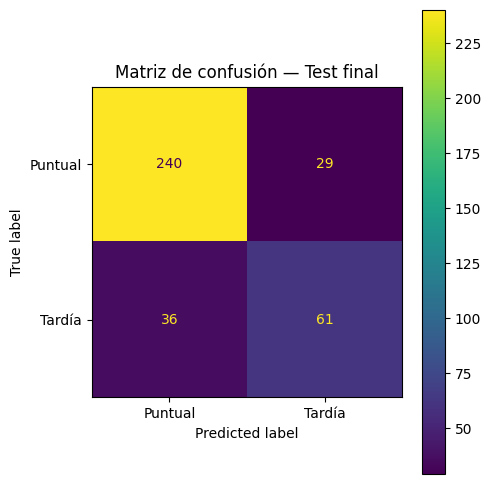

In [21]:
fig, ax = plt.subplots(
    figsize=(5, 5)
)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=[
        "Puntual",
        "Tardía"
    ],
    values_format="d",
    ax=ax,
)

ax.set_title(
    "Matriz de confusión — Test final"
)

plt.tight_layout()
plt.show()

## 7. Comparación con el período de validation

Para interpretar la generalización temporal se compararán las métricas de test con las obtenidas durante la selección del Modelo C.

Es importante señalar que las métricas de validation pertenecen al modelo utilizado durante el desarrollo, entrenado exclusivamente con train.

El modelo final de test fue posteriormente reentrenado utilizando `train + validation`.

Por tanto, la comparación no representa exactamente el mismo estimador ajustado sobre dos conjuntos distintos, sino el comportamiento observado durante:

- fase de selección;
- evaluación final del sistema reentrenado.

Esta comparación se utiliza para estudiar la estabilidad temporal del proceso completo, no para reajustar decisiones.

### Metricas congeladas de validation

In [22]:
validation_reference = pd.Series({
    "accuracy": (
        (199 + 112) / 381
    ),

    "balanced_accuracy": 0.838772,

    "precision": 0.658824,

    "recall": 0.903226,

    "f1": 0.761905,

    "f2": 0.840841,

    "roc_auc": 0.904387,

    "pr_auc": 0.801798,

    "brier_score": 0.1219,

    "log_loss": 0.3960,
})

validation_reference

accuracy             0.816273
balanced_accuracy    0.838772
precision            0.658824
recall               0.903226
f1                   0.761905
f2                   0.840841
roc_auc              0.904387
pr_auc               0.801798
brier_score          0.121900
log_loss             0.396000
dtype: float64

### Validation vs Test

In [23]:
validation_vs_test = pd.DataFrame({
    "validation": validation_reference,
    "test": test_metrics,
})

validation_vs_test[
    "delta_test_minus_validation"
] = (
    validation_vs_test["test"]
    - validation_vs_test["validation"]
)

validation_vs_test

,validation,test,delta_test_minus_validation
accuracy,0.816273,0.822404,0.006131
balanced_accuracy,0.838772,0.760530,-0.078242
precision,0.658824,0.677778,0.018954
recall,0.903226,0.628866,-0.274360
f1,0.761905,0.652406,-0.109499
f2,0.840841,0.638075,-0.202766
roc_auc,0.904387,0.859043,-0.045344
pr_auc,0.801798,0.693359,-0.108439
brier_score,0.121900,0.132432,0.010532
log_loss,0.396000,0.411998,0.015998


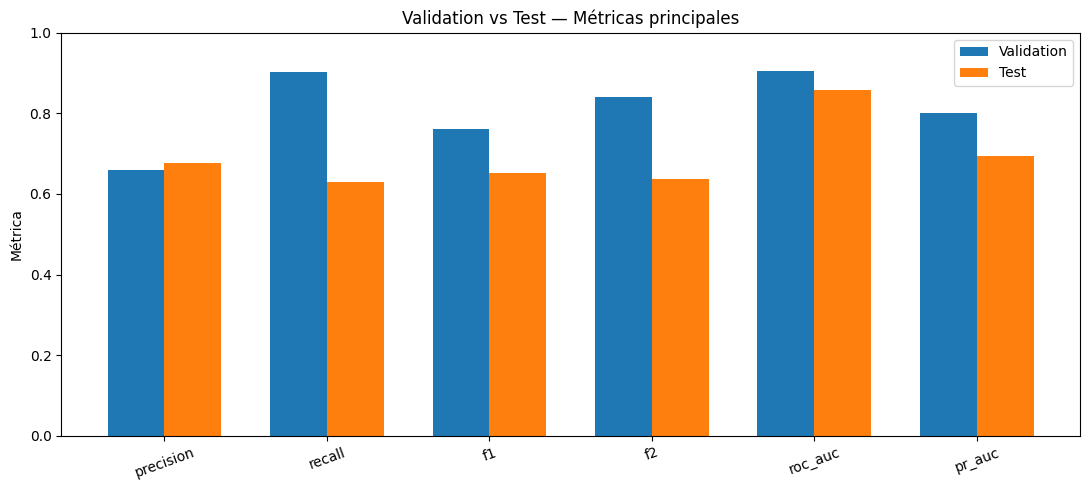

In [24]:
metrics_to_plot = [
    "precision",
    "recall",
    "f1",
    "f2",
    "roc_auc",
    "pr_auc",
]

comparison_plot = (
    validation_vs_test
    .loc[
        metrics_to_plot,
        [
            "validation",
            "test"
        ]
    ]
)

x = np.arange(
    len(comparison_plot)
)

width = 0.35

fig, ax = plt.subplots(
    figsize=(11, 5)
)

ax.bar(
    x - width / 2,
    comparison_plot["validation"],
    width,
    label="Validation"
)

ax.bar(
    x + width / 2,
    comparison_plot["test"],
    width,
    label="Test"
)

ax.set_xticks(x)

ax.set_xticklabels(
    comparison_plot.index,
    rotation=20
)

ax.set_ylim(
    0,
    1
)

ax.set_title(
    "Validation vs Test — Métricas principales"
)

ax.set_ylabel(
    "Métrica"
)

ax.legend()

plt.tight_layout()
plt.show()

### Lectura de la generalización temporal

La comparación muestra que el modelo mantiene una capacidad de discriminación relevante sobre test, aunque el rendimiento disminuye respecto a validation.

La caída más importante aparece en las métricas dependientes del threshold.

En particular, el Recall pasa aproximadamente de:

`90,3 % → 62,9 %`

Esto significa que el threshold `0.40`, seleccionado para detectar al menos el 90 % de los retrasos en validation, no mantiene el mismo punto operativo en el período futuro.

Sin embargo, la capacidad de ranking se deteriora de forma menos intensa:

- ROC-AUC: aproximadamente `0,904 → 0,859`;
- PR-AUC: aproximadamente `0,802 → 0,693`.

Por tanto, el modelo continúa diferenciando razonablemente bien las facturas de mayor y menor riesgo, aunque la traducción del score continuo a una decisión binaria mediante un threshold fijo resulta menos estable temporalmente.

Este resultado refuerza la importancia de separar:

- calidad del ranking de riesgo;
- selección del punto operativo de alertas.

### ROC-Curve final

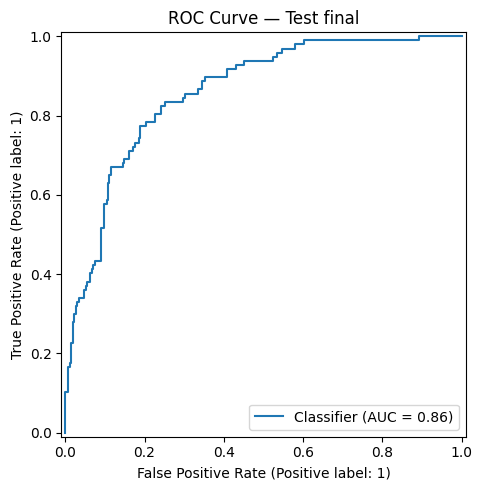

In [25]:
fig, ax = plt.subplots(
    figsize=(7, 5)
)

RocCurveDisplay.from_predictions(
    y_test,
    y_test_prob,
    ax=ax,
)

ax.set_title(
    "ROC Curve — Test final"
)

plt.tight_layout()
plt.show()

### Precision-Recall Curve final

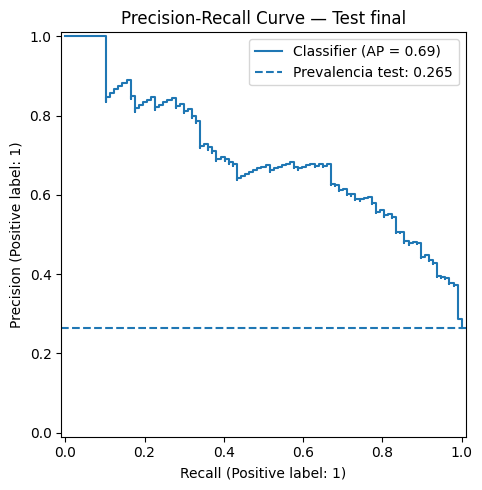

In [26]:
fig, ax = plt.subplots(
    figsize=(7, 5)
)

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_test_prob,
    ax=ax,
)

ax.axhline(
    y_test.mean(),
    linestyle="--",
    label=(
        "Prevalencia test: "
        f"{y_test.mean():.3f}"
    )
)

ax.set_title(
    "Precision-Recall Curve — Test final"
)

ax.legend()

plt.tight_layout()
plt.show()

### Interpretación de la capacidad de ranking en test

La prevalencia de retraso en test es aproximadamente:

`26,5 %`

Por tanto, un sistema sin capacidad predictiva tendría una Average Precision próxima a `0,265`.

El modelo final alcanza:

`PR-AUC ≈ 0,693`

Este resultado es considerablemente superior a la prevalencia del período y confirma que el modelo conserva capacidad para priorizar facturas según su riesgo.

Aunque el rendimiento disminuye respecto a validation, el scoring continuo sigue aportando información útil.

Esto sugiere que, en una aplicación empresarial, el modelo puede ser especialmente valioso como herramienta de priorización de recobros incluso cuando un threshold fijo presenta menor estabilidad temporal.

### Probabilidad media vs prevalencia de test

In [27]:
test_probability_summary = pd.Series({
    "mean_predicted_probability": (
        y_test_prob.mean()
    ),

    "observed_positive_rate": (
        y_test.mean()
    ),

    "difference": (
        y_test_prob.mean()
        - y_test.mean()
    ),
})

test_probability_summary

mean_predicted_probability    0.245056
observed_positive_rate        0.265027
difference                   -0.019971
dtype: float64

## 8. Diagnóstico probabilístico sobre test

La probabilidad media estimada por el modelo final es aproximadamente del 24,5 %, mientras que la tasa real de retraso en test es cercana al 26,5 %.

La diferencia global es de aproximadamente -2 puntos porcentuales.

Esto representa una mejora respecto a la sobreestimación observada durante validation, donde la probabilidad media predicha era considerablemente superior a la frecuencia real.

No obstante, la proximidad entre las medias no garantiza por sí sola una calibración correcta en todos los niveles de riesgo.

Por este motivo se analizará la reliability curve sobre test únicamente con carácter diagnóstico.

Los resultados no se utilizarán para recalibrar el modelo.

### Calibration Curve final

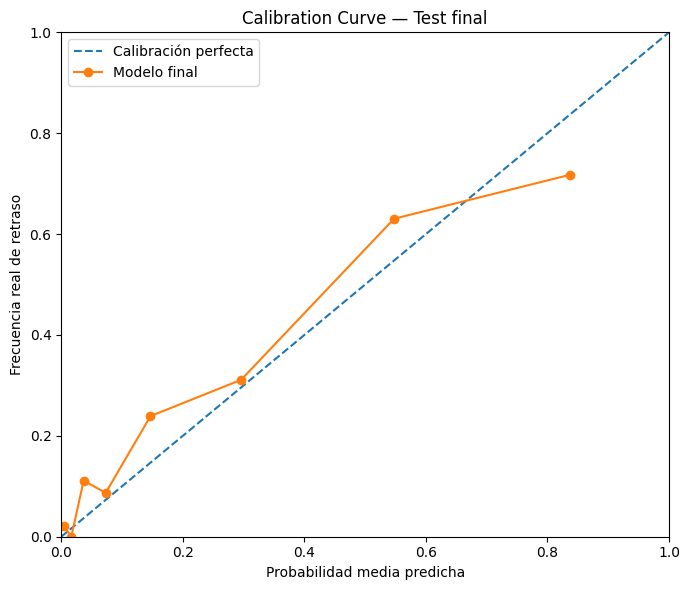

In [28]:
test_prob_true, test_prob_pred = (
    calibration_curve(
        y_test,
        y_test_prob,
        n_bins=8,
        strategy="quantile",
    )
)

fig, ax = plt.subplots(
    figsize=(7, 6)
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Calibración perfecta"
)

ax.plot(
    test_prob_pred,
    test_prob_true,
    marker="o",
    label="Modelo final"
)

ax.set_title(
    "Calibration Curve — Test final"
)

ax.set_xlabel(
    "Probabilidad media predicha"
)

ax.set_ylabel(
    "Frecuencia real de retraso"
)

ax.set_xlim(
    0,
    1
)

ax.set_ylim(
    0,
    1
)

ax.legend()

plt.tight_layout()
plt.show()

### Tabla calibracion test

In [29]:
test_calibration_table = pd.DataFrame({
    "mean_predicted_probability": (
        test_prob_pred
    ),

    "observed_late_rate": (
        test_prob_true
    ),
})

test_calibration_table[
    "calibration_error"
] = (
    test_calibration_table[
        "observed_late_rate"
    ]
    -
    test_calibration_table[
        "mean_predicted_probability"
    ]
)

test_calibration_table[
    "absolute_calibration_error"
] = (
    test_calibration_table[
        "calibration_error"
    ]
    .abs()
)

test_calibration_table

,mean_predicted_probability,observed_late_rate,calibration_error,absolute_calibration_error
0,0.003856,0.021739,0.017883,0.017883
1,0.016443,0.000000,-0.016443,0.016443
2,0.036836,0.111111,0.074275,0.074275
3,0.073014,0.086957,0.013943,0.013943
4,0.146814,0.239130,0.092317,0.092317
5,0.295934,0.311111,0.015177,0.015177
6,0.547608,0.630435,0.082827,0.082827
7,0.836527,0.717391,-0.119135,0.119135


### ECE de test

In [30]:
def calculate_ece(
    y_true,
    y_prob,
    n_bins=8
):
    calibration_data = pd.DataFrame({
        "y_true": np.asarray(y_true),
        "y_prob": np.asarray(y_prob),
    })

    calibration_data["bin"] = pd.qcut(
        calibration_data["y_prob"],
        q=n_bins,
        duplicates="drop",
    )

    table = (
        calibration_data
        .groupby(
            "bin",
            observed=True
        )
        .agg(
            n=("y_true", "size"),
            mean_predicted_probability=(
                "y_prob",
                "mean"
            ),
            observed_late_rate=(
                "y_true",
                "mean"
            ),
        )
        .reset_index()
    )

    table["absolute_error"] = (
        table[
            "mean_predicted_probability"
        ]
        -
        table[
            "observed_late_rate"
        ]
    ).abs()

    ece = (
        (
            table["n"]
            / len(calibration_data)
        )
        *
        table["absolute_error"]
    ).sum()

    return ece

In [31]:
test_ece = calculate_ece(
    y_test,
    y_test_prob,
    n_bins=8
)

print(
    "Test ECE:",
    f"{test_ece:.3%}"
)

Test ECE: 5.405%


### Brier Skill Score final

In [32]:
final_train_prevalence = (
    y_final_train.mean()
)

naive_test_probability = np.full(
    len(y_test),
    final_train_prevalence
)

naive_test_brier = (
    brier_score_loss(
        y_test,
        naive_test_probability
    )
)

final_brier_skill_score = (
    1
    - test_metrics["brier_score"]
    / naive_test_brier
)

print(
    "Final train prevalence:",
    f"{final_train_prevalence:.3%}"
)

print(
    "Naive test Brier:",
    f"{naive_test_brier:.4f}"
)

print(
    "Model test Brier:",
    f"{test_metrics['brier_score']:.4f}"
)

print(
    "Brier Skill Score:",
    f"{final_brier_skill_score:.3f}"
)

Final train prevalence: 37.143%
Naive test Brier: 0.2061
Model test Brier: 0.1324
Brier Skill Score: 0.357


## 9. Estabilidad del threshold

El resultado más débil de la evaluación final se encuentra en la estabilidad del threshold operativo.

El threshold `0.40` fue seleccionado sobre validation porque permitía detectar aproximadamente el 90 % de los retrasos reales manteniendo una Precision razonable.

En test, utilizando exactamente el mismo threshold, el Recall desciende hasta aproximadamente el 63 %.

Este resultado no implica que el scoring continuo haya dejado de funcionar, ya que ROC-AUC y PR-AUC siguen siendo claramente superiores a sus referencias aleatorias.

La principal conclusión es que un threshold fijo puede ser sensible a:

- cambios de prevalencia;
- cambios en la distribución de las features;
- variaciones en la relación entre score y resultado;
- reentrenamiento del modelo con información temporal adicional.

En una aplicación real sería recomendable monitorizar periódicamente:

- distribución de scores;
- prevalencia real de retrasos;
- Recall y Precision;
- calibration curve;
- drift de features y target.

El threshold podría revisarse de forma periódica utilizando únicamente información histórica ya observada, nunca utilizando resultados futuros.

### Analisis de errores: falsos negativos

In [33]:
test_predictions = (
    test_df[
        [
            "invoice_id",
            "customer_id",
            "invoice_date",
            "invoice_amount",
            "late_payment",
            "previous_late_rate",
            "previous_avg_delay",
            "previous_median_delay",
            "last_5_late_rate",
        ]
    ]
    .copy()
)

test_predictions[
    "predicted_risk"
] = y_test_prob

test_predictions[
    "prediction"
] = y_test_pred

false_negatives_df = (
    test_predictions[
        (test_predictions["late_payment"] == 1)
        &
        (test_predictions["prediction"] == 0)
    ]
    .sort_values(
        "predicted_risk",
        ascending=False
    )
)

print(
    "Falsos negativos:",
    len(false_negatives_df)
)

false_negatives_df.head(15)

Falsos negativos: 36


,invoice_id,customer_id,invoice_date,invoice_amount,late_payment,previous_late_rate,previous_avg_delay,previous_median_delay,last_5_late_rate,predicted_risk,prediction
2462,2455126326,8887-NCUZC,2013-12-02,49.51,1,0.617647,2.970588,3.0,0.6,0.391074,0
2344,8427086210,1447-YZKCL,2013-10-30,87.27,1,0.619048,3.285714,5.0,0.6,0.384171,0
2177,176953642,9323-NDIOV,2013-09-10,65.00,1,0.444444,3.611111,-0.5,0.0,0.378086,0
2135,3289097967,1080-NDGAE,2013-08-30,82.60,1,0.541667,1.083333,1.5,0.8,0.377456,0
2243,6830035207,8887-NCUZC,2013-09-26,31.45,1,0.620690,3.379310,4.0,0.6,0.329961,0
2450,4025313129,9323-NDIOV,2013-11-29,84.38,1,0.391304,2.695652,-1.0,0.2,0.326358,0
2413,4701158835,1080-NDGAE,2013-11-18,83.59,1,0.551724,0.344828,2.0,0.6,0.315427,0
2394,5144461624,1080-NDGAE,2013-11-13,101.93,1,0.571429,0.642857,2.0,0.6,0.308308,0
2353,4381512590,9323-NDIOV,2013-11-02,68.28,1,0.409091,3.045455,-0.5,0.2,0.285802,0
2282,6014957446,8887-NCUZC,2013-10-09,55.55,1,0.620690,3.379310,4.0,0.6,0.278628,0


### Falsos positivos

In [34]:
false_positives_df = (
    test_predictions[
        (test_predictions["late_payment"] == 0)
        &
        (test_predictions["prediction"] == 1)
    ]
    .sort_values(
        "predicted_risk",
        ascending=False
    )
)

print(
    "Falsos positivos:",
    len(false_positives_df)
)

false_positives_df.head(15)

Falsos positivos: 29


,invoice_id,customer_id,invoice_date,invoice_amount,late_payment,previous_late_rate,previous_avg_delay,previous_median_delay,last_5_late_rate,predicted_risk,prediction
2366,1056254354,0783-PEPYR,2013-11-06,71.78,0,1.000000,9.777778,11.0,1.0,0.926983,1
2161,9359250752,0688-XNJRO,2013-09-06,25.07,0,0.960000,15.280000,15.0,1.0,0.926187,1
2370,6452306428,4460-ZXNDN,2013-11-06,56.03,0,0.961538,13.115385,11.0,1.0,0.880666,1
2373,6878680146,4460-ZXNDN,2013-11-07,52.84,0,0.961538,13.115385,11.0,1.0,0.846590,1
2401,9238366168,5573-KSOIA,2013-11-14,104.58,0,0.952381,8.714286,7.0,0.8,0.807159,1
2175,1120525583,9883-SDWFS,2013-09-10,46.73,0,0.791667,7.125000,7.0,1.0,0.771134,1
2150,8455537995,4632-QZOKX,2013-09-02,47.24,0,0.928571,8.285714,7.0,0.8,0.747404,1
2261,5506147573,5573-KSOIA,2013-10-02,84.31,0,1.000000,9.450000,7.5,1.0,0.735437,1
2147,5854224600,3831-FXWYK,2013-09-02,56.31,0,0.809524,6.476190,6.0,0.6,0.726839,1
2254,5411405629,3448-OWJOT,2013-09-30,73.99,0,0.833333,6.958333,7.0,0.6,0.713426,1


## 10. Análisis de errores

El análisis individual de falsos positivos y falsos negativos no se utiliza para modificar el modelo final.

Su finalidad es comprender qué tipo de facturas resultan más difíciles de clasificar.

Los falsos negativos son especialmente relevantes porque representan facturas que el sistema considera de bajo riesgo pero que finalmente pagan tarde.

Los falsos positivos representan alertas que habrían requerido atención del equipo financiero aunque finalmente la factura fuese pagada puntualmente.

En una futura aplicación real, este análisis podría utilizarse para identificar nuevos tipos de información que actualmente no están disponibles en el dataset, como:

- incidencias administrativas;
- promesas de pago;
- situación financiera externa del cliente;
- disputas conocidas en el momento de predicción;
- cambios recientes en las condiciones comerciales.

### Porcentaje de facturas marcadas como riesgo

In [35]:
alert_rate_test = (
    y_test_pred.mean()
)

print(
    "Facturas marcadas como riesgo:",
    y_test_pred.sum()
)

print(
    "Porcentaje de test marcado como riesgo:",
    f"{alert_rate_test:.2%}"
)

Facturas marcadas como riesgo: 90
Porcentaje de test marcado como riesgo: 24.59%


### Tabla final operativa

In [36]:
final_operational_summary = pd.Series({
    "test_invoices": len(y_test),

    "real_late_invoices": (
        tp + fn
    ),

    "detected_late_invoices": tp,

    "missed_late_invoices": fn,

    "false_alerts": fp,

    "total_alerts": (
        tp + fp
    ),

    "test_prevalence": (
        y_test.mean()
    ),

    "alert_rate": (
        y_test_pred.mean()
    ),

    "recall": (
        tp / (tp + fn)
    ),

    "precision": (
        tp / (tp + fp)
    ),

    "missed_late_rate": (
        fn / (tp + fn)
    ),

    "false_alert_rate_among_alerts": (
        fp / (tp + fp)
    ),
})

final_operational_summary

test_invoices                    366.000000
real_late_invoices                97.000000
detected_late_invoices            61.000000
missed_late_invoices              36.000000
false_alerts                      29.000000
total_alerts                      90.000000
test_prevalence                    0.265027
alert_rate                         0.245902
recall                             0.628866
precision                          0.677778
missed_late_rate                   0.371134
false_alert_rate_among_alerts      0.322222
dtype: float64

# Conclusiones finales de la evaluación

El objetivo de este notebook era realizar una única evaluación final del sistema sobre un período temporal completamente reservado durante todo el desarrollo.

Antes de abrir test quedaron congeladas todas las decisiones:

- 34 features correspondientes al Modelo C;
- Logistic Regression;
- sin calibración externa;
- threshold operativo = 0.40.

Posteriormente, el modelo fue reentrenado utilizando conjuntamente train y validation y evaluado una única vez sobre test.

## Composición del período de test

El conjunto final contiene:

- 366 facturas;
- 97 facturas pagadas tarde;
- 269 facturas puntuales o anticipadas;
- prevalencia de retraso = 26,5 %.

La prevalencia continúa la tendencia descendente observada durante el proyecto:

- train ≈ 38,2 %;
- validation ≈ 32,5 %;
- test ≈ 26,5 %.

Esto confirma la existencia de un cambio temporal relevante en la distribución del target.

## Rendimiento final

El modelo obtiene sobre test:

- Accuracy = 82,2 %;
- Balanced Accuracy = 76,1 %;
- Precision = 67,8 %;
- Recall = 62,9 %;
- F1 = 65,2 %;
- F2 = 63,8 %;
- ROC-AUC = 85,9 %;
- PR-AUC = 69,3 %.

La capacidad de discriminación disminuye respecto a validation, pero continúa claramente por encima de una referencia aleatoria.

La prevalencia de la clase positiva en test es del 26,5 %, mientras que PR-AUC alcanza aproximadamente 69,3 %.

Por tanto, el modelo continúa siendo capaz de priorizar las facturas de mayor riesgo de forma informativa.

## Matriz de confusión

Utilizando el threshold congelado de 0.40:

- 240 facturas puntuales son correctamente identificadas;
- 29 facturas puntuales generan una falsa alarma;
- 61 facturas tardías son correctamente detectadas;
- 36 facturas tardías no son detectadas.

De las 97 facturas que realmente pagan tarde, el modelo anticipa 61.

Esto implica un Recall final del 62,9 %.

La Precision alcanza el 67,8 %, lo que significa que aproximadamente dos de cada tres alertas corresponden realmente a facturas que terminan pagando tarde.

## Generalización temporal

La mayor caída respecto a validation se produce en las métricas dependientes del threshold.

El Recall pasa aproximadamente de:

`90,3 % → 62,9 %`

mientras que ROC-AUC pasa de:

`0,904 → 0,859`

y PR-AUC de:

`0,802 → 0,693`.

Este comportamiento indica que la capacidad de ranking del modelo es más estable que el punto operativo determinado por un threshold fijo.

Por tanto, una de las principales conclusiones del proyecto es que debe distinguirse entre:

- scoring continuo de riesgo;
- clasificación binaria mediante un threshold.

El primero muestra una generalización temporal razonable.

El segundo es considerablemente más sensible al cambio de distribución.

## Estabilidad del threshold

El threshold de 0.40 fue seleccionado utilizando exclusivamente validation porque permitía mantener un Recall superior al 90 % con una Precision razonable.

Ese nivel de sensibilidad no se reproduce en test.

Por tanto, el threshold seleccionado sobre un único período temporal no puede considerarse completamente estable.

No se modificará el threshold después de observar test, ya que hacerlo convertiría test en un nuevo conjunto de validación e invalidaría la evaluación final.

En una futura versión del sistema sería recomendable seleccionar y monitorizar el threshold mediante múltiples ventanas temporales o validación walk-forward.

## Comportamiento probabilístico

El riesgo medio estimado sobre test es aproximadamente:

`24,5 %`

frente a una tasa real de retraso de:

`26,5 %`.

La diferencia global es de aproximadamente 2 puntos porcentuales.

El Expected Calibration Error utilizando 8 bins cuantiles es aproximadamente:

`ECE = 5,4 %`.

El modelo obtiene además:

- Brier Score = 0,132;
- Log Loss = 0,412.

Frente a un modelo ingenuo basado únicamente en la prevalencia histórica, el Brier Skill Score es aproximadamente:

`0,357`.

Esto indica que el modelo reduce alrededor de un 36 % el error probabilístico cuadrático frente a dicha referencia.

Las probabilidades no son perfectamente calibradas en todos los niveles de riesgo, pero mantienen utilidad como scoring probabilístico.

## Análisis de errores

Los falsos positivos se concentran en gran medida en clientes con históricos de retraso elevados.

En estos casos, el modelo asigna correctamente un riesgo alto a partir de la información disponible, aunque una factura concreta pueda finalmente pagarse de forma puntual.

Los falsos negativos muestran que el comportamiento de pago no es completamente determinista y que el histórico disponible no permite anticipar todos los retrasos futuros.

Esto sugiere que futuras mejoras podrían requerir información actualmente no disponible, por ejemplo:

- incidencias administrativas;
- cambios recientes en las condiciones comerciales;
- disputas conocidas en el momento de predicción;
- promesas de pago;
- información financiera externa del cliente.

## Veredicto final del modelo

La evaluación final confirma que el modelo contiene una señal predictiva real y útil.

La regresión logística es capaz de ordenar las facturas según su riesgo de retraso con una capacidad de discriminación considerable:

- ROC-AUC = 0,859;
- PR-AUC = 0,693.

Sin embargo, el threshold fijo de 0.40 no generaliza con la sensibilidad observada durante validation y únicamente detecta aproximadamente el 63 % de los retrasos en test.

Por tanto, el sistema debe considerarse más sólido como **herramienta de scoring y priorización de riesgo** que como clasificador binario basado en un threshold estático.

El modelo puede utilizarse para:

- ordenar facturas por riesgo;
- priorizar acciones de seguimiento;
- identificar clientes y facturas que requieren mayor atención;
- aportar una señal de riesgo a futuros sistemas de planificación de tesorería.

No debería presentarse como un sistema capaz de garantizar la detección de todos los retrasos ni como un modelo de impago definitivo.

## Limitaciones

Las principales limitaciones del modelo son:

- dataset relativamente pequeño;
- únicamente 100 clientes;
- histórico de aproximadamente dos años;
- todos los plazos de pago son de 30 días;
- ausencia de impagos definitivos;
- cambio temporal significativo en la prevalencia;
- features históricas parcialmente redundantes;
- ausencia de información externa o cualitativa sobre los clientes.

Estas limitaciones condicionan la generalización del sistema y deberán considerarse antes de cualquier utilización empresarial real.

## Conclusión

El proyecto demuestra que el comportamiento histórico de pago contiene suficiente información para construir un sistema predictivo útil de riesgo de retraso.

El modelo final mantiene capacidad predictiva sobre un período futuro completamente independiente, aunque con una degradación respecto a validation.

La principal aportación del sistema es por tanto un **score continuo de riesgo de retraso**, interpretable y útil para priorizar la gestión de cobros.

La evaluación final del modelo se considera cerrada.

No se realizarán más modificaciones utilizando información procedente de test.